<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_15_Matplotlib Scatter Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🟨 Median Yearly Salary vs. Job Count (2.15.1)

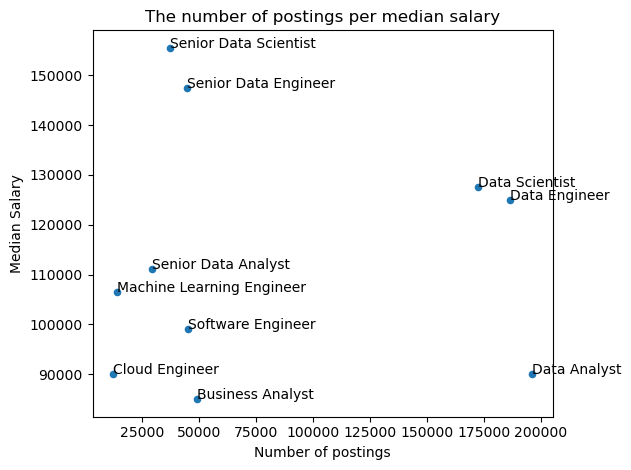

In [13]:
df_new = ( 
    df.groupby('job_title_short').agg( 
    median_salary = ('salary_year_avg', 'median'),
    num_postings = ('job_title_short', 'size')    
    )
)
df_new.plot(kind = 'scatter',
         x = 'num_postings',
         y = 'median_salary',
         ylabel = 'Median Salary',
         xlabel = 'Number of postings',
         title = 'The number of postings per median salary')

for i, j in enumerate(df_new.index):
    plt.text(df_new['num_postings'].iloc[i], df_new['median_salary'].iloc[i], j)

plt.tight_layout()

---

## 🟨 Top 7 Countries by Median Yearly Salary vs Job Count  (2.15.2)

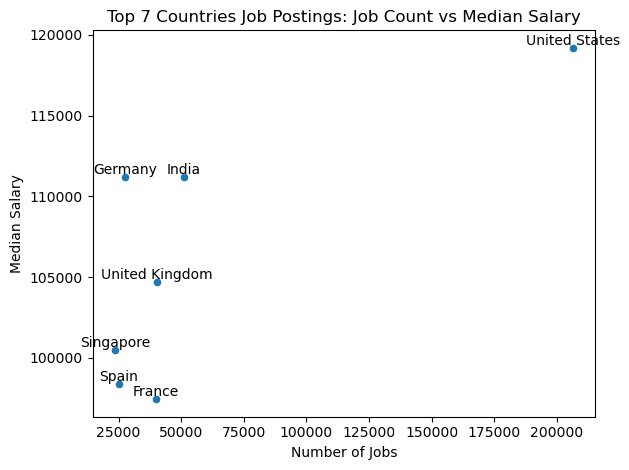

In [40]:
df_countries = (
    df.groupby('job_country').agg(
        num_postings = ('job_title_short','size'),
        median_salary = ('salary_year_avg', 'median')
    )
)


df_countries_7 = (
    df_countries.sort_values(by = 'num_postings', ascending = False)
    .head(7)
)
df_countries_7.plot(kind = 'scatter', x = 'num_postings', y = 'median_salary', xlabel = 'Number of Jobs', ylabel = 'Median Salary', title = 'Top 7 Countries Job Postings: Job Count vs Median Salary')

for i, j in enumerate(df_countries_7.index):
    plt.text(df_countries_7['num_postings'].iloc[i], df_countries_7['median_salary'].iloc[i], j, ha = 'center', va = 'bottom')

plt.tight_layout()

---

## 🟥 Average Yearly Salary vs. Job Count for Top Roles by Schedule Type (2.15.3)

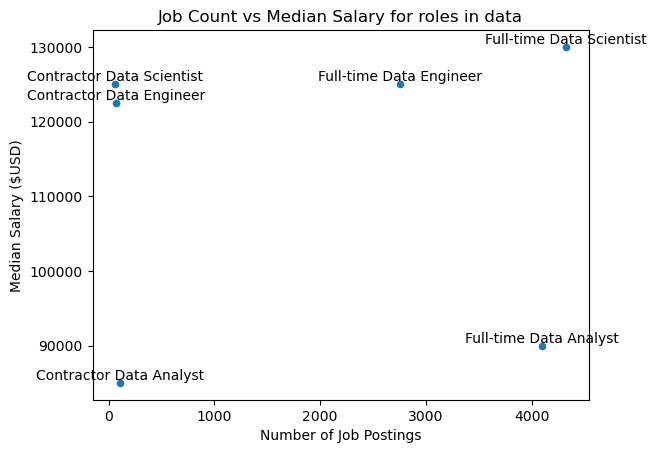

In [ ]:
# Code Needed
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[
    (df['job_country'] == 'United States') &
    (df['job_schedule_type'].isin(['Full-time','Contractor'])) &
    (df['job_title_short'].isin(target_job_titles))

]
df_filtered = df_filtered.dropna(subset = ['salary_year_avg'])
df_filtered['job_title_type'] = df['job_schedule_type'] + ' ' + df['job_title_short']
df_filtered_group = df_filtered.groupby('job_title_type').agg(
median_salary = ('salary_year_avg','median'),
job_postings = ('job_title_short','size')
)
df_filtered_group.plot(kind = 'scatter', x = 'job_postings', y = 'median_salary', xlabel = 'Number of Job Postings', ylabel = 'Median Salary ($USD)', title = 'Job Count vs Median Salary for roles in data')
for i, j in enumerate(df_filtered_group.index):
    plt.text(df_filtered_group['job_postings'].iloc[i], df_filtered_group['median_salary'].iloc[i], j, ha = 'center', va = 'bottom')

#for job_title_type in stats['job_title_type'].unique():
   #subset = stats[stats['job_title_type'] == job_title_type]
   #plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

---

In [42]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
